# Quantum Jam 2025: Clase 2 - Soluciones

<img src= "https://raw.githubusercontent.com/santiago-feldman/Quantum-Computing-and-Qiskit-v2.X-notebooks/main/images/Fall%20Fest%20Graphics/Illustration%20Exports/Full_Illustration.png" />

In [ ]:
!pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer qiskit_qasm3_import

import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_bloch_vector
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter, ParameterVector
import qiskit.qasm3
from qiskit_ibm_runtime.fake_provider import FakeVigoV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, EstimatorV2 as Estimator, QiskitRuntimeService

## Ejercicio 1: operadores de Pauli (operadores de un solo qubit)

Los operadores de Pauli (X, Y, Z e I) son matrices de 2x2 que representan operaciones elementales de un solo qubit. En Qiskit, se pueden crear usando la clase `Pauli` (ejemplo: `Pauli('X')` para el operador X). También se pueden construir Paulis de múltiples qubits especificando caracteres para cada qubit (ejemplo: `'IX'` para la identidad en el qubit 0 y X en el qubit 1, siguiendo el ordenamiento de bits "little-endian" de Qiskit).

Escribe un código que realice lo siguiente:
1. Crea un operador de Pauli de 3 qubits representando `Z` en el qubit 2, `Y` en el qubit 1 e `I` (identidad) en el qubit 0.
2. Imprime el operador.
3. Imprime la representación matricial correspondiente.

In [4]:
# Escribe tu código aquí
pauli_op = Pauli('ZYI')

print(pauli_op)
print(pauli_op.to_matrix())

ZYI
[[0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+1.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+1.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j]]


## Ejercicio 2: compuertas y fases de un solo qubit

Las compuertas de un solo qubit, como X, Y, Z, H, S y T, son operaciones básicas que actúan sobre un qubit. Las compuertas S y T son compuertas de fase. La compuerta S introduce una fase de π/2 en el componente ∣1⟩ de cualquier estado cuántico, mientras que la compuerta T introduce un desfase de π/4 en el componente ∣1⟩, manteniendo inalterado el componente ∣0⟩ en ambos casos. Estos cambios de fase son cruciales en muchos algoritmos cuánticos.

Escribe un código que realice lo siguiente:
1. Crea un circuito cuántico de un qubit.
2. Pone al qubit en el estado $|1\rangle$.
3. Añade una sola compuerta al circuito que aplica una fase de π/4 al qubit.
4. Muestra la representación en notación de Dirac del vector de estado del circuito.

In [5]:
# Escribe tu código aquí
qc = QuantumCircuit(1)
qc.x(0)

qc.t(0)

statevector = Statevector(qc)
statevector.draw('latex', prefix='Statevector: ')

<IPython.core.display.Latex object>

## Ejercicio 3: superposición y rotaciones en la esfera de Bloch

Las compuertas como `RX`, `RY` y `RZ` realizan rotaciones alrededor de los ejes de la esfera de Bloch, creando una superposición de estados. Una rotación por un ángulo θ alrededor del eje Y (`RY(θ)`) en un estado inicial |0⟩ produce la superposición cos(θ/2)|0⟩ + sin(θ/2)|1⟩. Las probabilidades de medir 0 ó 1 son el cuadrado de estas amplitudes.

Escribe un código que realice lo siguiente:

1. Crea un circuito cuántico de un qubit.
2. Aplica una única compuerta al qubit 0 (inicialmente en el estado |0⟩) para crear una superposición donde la probabilidad de medir |0⟩ sea aproximadamente 14.6% y la probabilidad de medir |1⟩ sea 85.4%.
3. Imprime las probabilidades.
4. Muestra la representación en la esfera de Bloch del vector de estado.

Probabilidades: {np.str_('0'): np.float64(0.1464466094067263), np.str_('1'): np.float64(0.8535533905932737)}


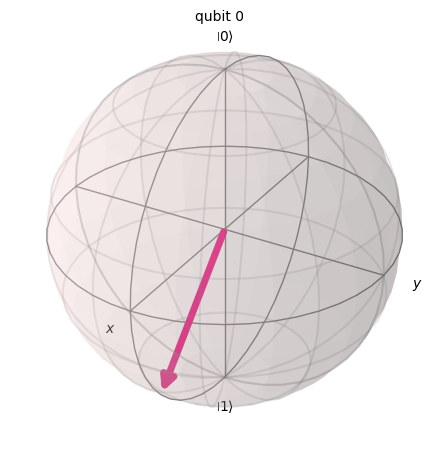

In [7]:
# Escribe tu código aquí
qc = QuantumCircuit(1)

qc.ry(3 * np.pi / 4, 0)

sv = Statevector(qc)
probs = sv.probabilities_dict()
print(f'Probabilidades: {probs}')
plot_bloch_multivector(sv)

## Ejercicio 4: entrelazamiento y operaciones de múltiples qubits

Algunas compuertas de múltiples qubits como la CNOT (qc.cx(control, target)) crean entrelazamiento cuando se las aplica a estados superpuestos. Un estado entrelazado común es el estado de Bell |Φ+⟩ = 1/√2(|00⟩ + |11⟩), que se crea aplicando una compuerta de Hadamard a un qubit y luego una compuerta CNOT. Recuerden el ordenamiento de bits de Qiskit: el qubit 0 es el de más a la derecha (el menos significativo).

Escribe un código que realice lo siguiente:

1. Crea un circuito cuántico de dos qubits.
2. Crea el estado de Bell |Φ+⟩, donde el primer qubit (q0) es el qubit de control.
3. Dibuja el circuito cuántico usando matplotlib.
4. Imprime el vector de estado del circuito.

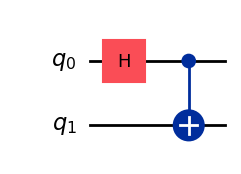

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [8]:
# Escribe tu código aquí
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

display(qc.draw('mpl'))
statevector = Statevector(qc)
print(statevector)

## Ejercicio 5: construyendo y dibujando circuitos cuánticos

La clase `QuantumCircuit` se usa para construir circuitos cuánticos. El método `draw()` proporciona visualizaciones en formatos como `'text'`, `'mpl'` y `'latex'`. Pueden personalizar el dibujo con parámetros como `reverse_bits` para dar vuelta el ordenamiento de qubits.

Escribe un código que realice lo siguiente:
1. Crea un estado GHZ de 3 qubits.
2. Dibuja el circuito con el ordenamiento de qubits revertido en el diagrama (q2 arriba, q0 abajo).

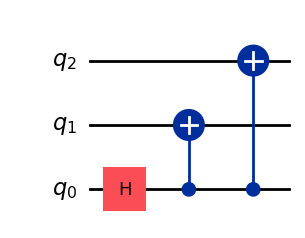

In [9]:
# Escribe tu código aquí
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)

qc.draw(output='mpl', reverse_bits=True)

## Ejercicio 6: circuitos dinámicos y flujo de control clásico

Qiskit admite circuitos dinámicos donde las operaciones pueden condicionarse a los resultados de las mediciones. El gestor de contexto (*context manager*) `if_test()` puede utilizarse para crear bloques condicionales donde las operaciones ejecutadas se basan en valores de bits clásicos. Esto nos permite una potente prealimentación (*feed-forward*) clásica en nuestros programas cuánticos.

Escribe un código que realice lo siguiente:

1. Crea un circuito cuántico con dos qubits y al menos un bit clásico.
2. Añade una compuerta de Hadamard al qubit menos significativo.
3. Aplica una compuerta X al qubit 1 *si y sólo si* una medición del qubit 0 produce el resultado `1`. Utiliza el gestor de contexto `if_test()` con la tupla de condición adecuada.
4. Dibuja el circuito usando matplotlib.

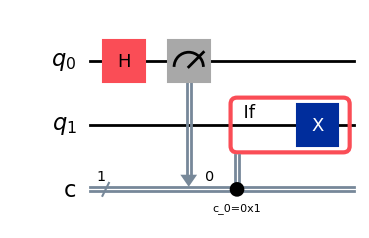

In [10]:
# Escribe tu código aquí
qc = QuantumCircuit(2, 1)
qc.h(0)
qc.measure(0, 0)

with qc.if_test((qc.clbits[0], 1)):
    qc.x(1)

qc.draw('mpl')

## Ejercicio 7: visualizando resultados y estados cuánticos

Qiskit ofrece varias funciones para visualizar resultados. `plot_histogram(counts)` se usa para mostrar resultados de mediciones de una simulación o una ejecución en un dispositivo real. Pueden ordenar los resultados para un análisis más fácil; por ejemplo, en base a la frecuencia de los resultados.

Escribe un código que realice lo siguiente:
1. Crea un circuito cuántico que contenga el estado de Bell |Φ+⟩.
2. Mide el resultado sobre cables clásicos.
3. Corre el circuito usando el simulador `AerSimulator`.
4. Obtiene el recuento de las mediciones.
5. Grafica un histograma con las barras ordenadas desde el resultado más común hasta el menos común.

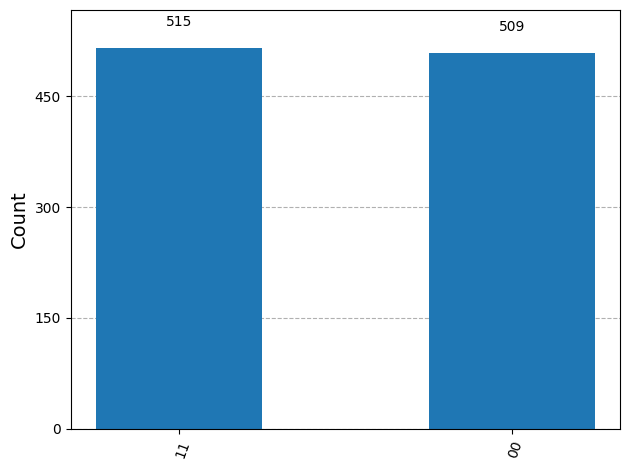

In [12]:
# Escribe tu código aquí
bell = QuantumCircuit(2, 2)
bell.h(0)
bell.cx(0, 1)
bell.measure([0, 1], [0, 1])

backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_bell = pm.run(bell)

sampler = Sampler(mode=backend)

job = sampler.run([isa_bell], shots=1024)
result = job.result()
counts = result[0].data.c.get_counts()

plot_histogram(counts, sort='value_desc')

## Ejercicio 8: circuitos cuánticos parametrizados

Qiskit admite circuitos con parámetros simbólicos usando la clase `Parameter`. Estos parámetros actúan como marcadores de posición (*placeholders*) que pueden vincularse a valores numéricos específicos más adelante mediante el método `assign_parameters()`. Esto es fundamental para algoritmos variacionales como VQE y QAOA.

Escribe un código que realice lo siguiente:
1. Instancia un `Parameter` para representar un parámetro llamado `theta`.
2. Crea el circuito cuántico `qc` de un qubit.
3. Añade la compuerta RX con el parámetro `theta` al cable del qubit.
4. Dibuja el circuito `qc`.
5. Crea un nuevo circuito `bound_qc` vinculando el parámetro `theta` al valor `π/2`.
6. Dibuja el circuito `bound_qc`.


Circuito original sin vincular:


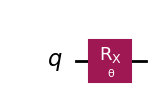

Nuevo circuito vinculado:


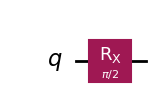

In [13]:
# Escribe tu código aquí
theta = Parameter('θ')
qc = QuantumCircuit(1)
qc.rx(theta, 0)

print('Circuito original sin vincular:')
display(qc.draw('mpl'))

bound_qc = qc.assign_parameters({theta: np.pi/2})

print('Nuevo circuito vinculado:')
bound_qc.draw('mpl')

## Ejercicio 9: transpilación y optimización de circuitos


La transpilación adapta un circuito cuántico a las limitaciones de un dispositivo cuántico específico, incluidas sus compuertas base y la conectividad entre qubits. La función `generate_preset_pass_manager()` crea un administrador de pases de transpilación con configuraciones preestablecidas. Tiene varias configuraciones de `optimization_level` (0-3), donde los niveles más altos aplican técnicas de optimización más avanzadas para reducir la profundidad del circuito y el número de compuertas, a costa de un mayor tiempo de compilación.

Escribe un código que realice lo siguiente:
1. Crea un circuito GHZ de 3 qubits.
2. Transpila el circuito para el backend `FakeVigoV2`, usando el nivel más alto de optimización (nivel 3).
3. Imprime la profundidad del circuito original.
4. Imprime la profundidad del circuito transpilado.
5. Dibuja el circuito transpilado.

Profundidad original: 3
Profundidad transpilación: 5


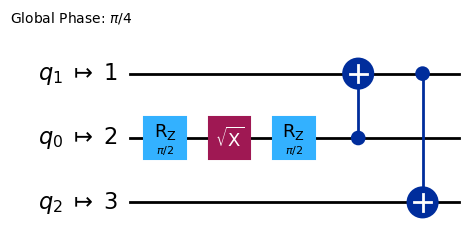

In [15]:
# Escribe tu código aquí
ghz = QuantumCircuit(3)
ghz.h(0)
ghz.cx(0, 1)
ghz.cx(1, 2)

backend = FakeVigoV2()
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

qc_isa = pm.run(ghz)

print(f'Profundidad original: {ghz.depth()}')
print(f'Profundidad transpilación: {qc_isa.depth()}')
qc_isa.draw('mpl')

## Ejercicio 10: modos de ejecución de Qiskit Runtime

Qiskit Runtime ofrece tres modos de ejecución: **job**, **session** y **batch**. Los modos de ejecución determinan cómo se programan nuestros trabajos en el cronograma de la computadora cuántica, y elegir el modo correcto permite que la carga de trabajo se ejecute eficientemente, sin exceder un presupuesto determinado.

Esta es una pregunta conceptual. En la celda a continuación, explique qué modo de ejecución (job, session o batch) utilizaría para un algoritmo VQE (Variational Quantum Eigensolver) y explique brevemente por qué.

In [16]:
# Escribe tu respuesta aquí:
# Deberías usar Session para un algoritmo VQE.
# Por qué: VQE es un algoritmo iterativo en el cual los resultados de una
# ejecución del circuito se utilizan para actualizar los parámetros en la
# siguiente ejecución. Una sesión mantiene una conexión con la QPU, lo que
# reduce significativamente la sobrecarga y la latencia entre estas llamadas
# iterativas, dando como resultado un tiempo de ejecución total mucho más rápido
# en comparación con enviar cada paso como un trabajo separado.

## Ejercicio 11: las primitivas Sampler y Estimator

Las primitivas son interfaces de alto nivel para tareas cuánticas comunes. **Sampler** y **Estimator** son dos primitivas claves que cumplen distintas funciones cuando se trabaja con circuitos cuánticos. Sirven para abstraer los detalles de la ejecución y la mitigación de errores, lo que facilita la extracción de información importante de la computación cuántica.

Esta es una pregunta conceptual. En la celda a continuación, describa en una oración la diferencia fundamental entre las primitivas Sampler y Estimator.

In [17]:
# Escribe tu respuesta aquí:
# Sampler genera distribuciones de probabilidad de los resultados de medición de
# un circuito cuántico, mientras que Estimator calcula los valores esperados de
# los observables especificados con respecto a un circuito cuántico.

## Ejercicio 12: usando la primitiva Sampler

En Qiskit, pueden usar la primitiva `Sampler` de `qiskit_ibm_runtime` con simuladores locales como `AerSimulator`. Acá, inicializarán `Sampler` en el modo backend, transpilarán su circuito utilizando `generate_preset_pass_manager` y luego usarán el método `.run([circuits], shots=...)`. El objeto resultante contendrá datos de mediciones accesibles mediante los nombres de registros clásicos.

Escribe un código que realice lo siguiente:
1. Crea un circuito cuántico que contenga el estado de Bell |Φ+⟩.
2. Usa el método `measure_all` para medir los resultados.
3. Transpila el circuito usando el backend `AerSimulator`.
4. Inicializa la primitiva `Sampler` con el backend `AerSimulator`.
5. Corre el Sampler.
6. Obtiene la cantidad de mediciones de cada resultado.
7. Imprime la cantidad de mediciones de cada resultado.

In [18]:
# Escribe tu código aquí
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_bell = pm.run(bell)

sampler = Sampler(mode=backend)

job = sampler.run([isa_bell], shots=5000)
result = job.result()

counts = result[0].data.meas.get_counts()
print(f'Cantidades de cada medición: {counts}')

Cantidades de cada medición: {'11': 2415, '00': 2585}


## Ejercicio 13: usando la primitiva Estimator

En Qiskit, pueden usar la primitiva `Estimator` de `qiskit_ibm_runtime` con simuladores locales como `AerSimulator`. `Estimator` ejecuta los valores esperados ⟨ψ|O|ψ⟩. Acá, inicializarán `Estimator` en el modo backend, transpilarán su circuito usando `generate_preset_pass_manager`, aplicarán el observable al layout del circuito y luego usarán el método `.run([(circuit, observable)])`. El objeto resultante contendrá los valores esperados, accesibles via `data.evs`.

Escribe un código que realice lo siguiente:
1. Crea un circuito cuántico que contenga el estado de Bell |Φ+⟩.
2. Define el observable ZZ usando `SparsePauliOp`.
3. Transpila el circuito usando el backend `AerSimulator`.
4. Aplica el observable al layout del circuito.
5. Inicializa la primitiva `Estimator` con el backend `AerSimulator`.
6. Corre el Estimator.
7. Obtiene el resultado PUB (Primitive Unified Block).
8. Recupera e imprime el valor esperado.

In [19]:
# Escribe tu código aquí
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

observable = SparsePauliOp('ZZ')

backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_bell = pm.run(bell)

isa_observable = observable.apply_layout(isa_bell.layout)

estimator = Estimator(mode=backend)

job = estimator.run([(isa_bell, isa_observable)])
result = job.result()

pub_result = result[0]
exp_val = pub_result.data.evs
print(f'Valor esperado de ZZ: {exp_val}')

Valor esperado de ZZ: 1.0


## Ejercicio 14: técnicas de mitigación de errores

Qiskit proporciona técnicas para reducir el impacto del ruido en el hardware cuántico. El **readout error mitigation** (mitigación de errores de lectura) corrige errores en el paso final de la medición. El **Dynamical Decoupling (DD)** (desacoplamiento dinámico) inserta secuencias de pulsos durante los tiempos de inactividad para proteger los qubits de la decoherencia. La **Zero-Noise Extrapolation (ZNE)** (extrapolación de ruido cero) corre circuitos con diferentes niveles de ruido y extrapola el resultado hasta el límite de ruido cero.

Esta es una pregunta conceptual. Estás ejecutando un circuito en un backend ruidoso y sospechas que los qubits pierden su estado cuántico (decoherencia) durante los periodos de inactividad del circuito. ¿Qué técnica de *supresión* de errores sería la más adecuada?


In [20]:
# Escribe tu respuesta aquí:
# La técnica más adecuada sería Dynamical Decoupling (DD). Está específicamente
# diseñada para combatir la decoherencia mediante la aplicación de pulsos
# cuidadosamente sincronizados a los qubits cuando no están participando
# activamente en una operación con compuertas, lo que permite re-enfocar su
# estado cuántico y protegerlo del ruido ambiental.

## Ejercicio 15: OpenQASM 3

OpenQASM 3 es la última versión del lenguaje ensamblador cuántico. Tiene una sintaxis más expresiva que su predecesor. Por ejemplo, declaramos un registro de 3 qubits con `qubit[3] my_qubits;` y un registro de bits clásicos con `bit[2] c;`.

Completa el string de OpenQASM 3 para crear un estado de Bell entre `q[0]` y `q[1]`.

In [21]:
qasm3_string = '''
OPENQASM 3.0;
include "stdgates.inc";
qubit[2] q;
bit[2] c;
h q[0];
cx q[0], q[1];

c = measure q;
'''

print(qasm3_string)


OPENQASM 3.0;
include "stdgates.inc";
qubit[2] q;
bit[2] c;
h q[0];
cx q[0], q[1];

c = measure q;



## Ejercicio 16: OpenQASM 3 vs. OpenQASM 2

OpenQASM 3 introdujo mejoras significativas con respecto a OpenQASM 2, destacando su expansión más allá de los circuitos simples basados ​​en compuertas. Una mejora importante involucra herramientas de programación que le permiten a los programas cuánticos tomar decisiones y repetir operaciones basándose en datos clásicos y resultados de mediciones, lo que permite la implementación de algoritmos cuánticos más dinámicos y adaptativos.

Esta es una pregunta conceptual. ¿Cuál es una característica importante relacionada con lógica clásica que está presente en OpenQASM 3 pero completamente ausente en OpenQASM 2?

In [22]:
# Escribe tu respuesta aquí:
# OpenQASM 3 admite un control de flujo clásico avanzado, que incluye
# estructuras como bucles for y while. OpenQASM 2, en cambio, no tenía ninguna
# capacidad de iteración.

## Ejercicio 17: OpenQASM con Qiskit

Qiskit provee las herramientas para convertir objetos de la clase `QuantumCircuit` a strings de OpenQASM 3 y viceversa. Para importar un string de OpenQASM 3 a un circuito de Qiskit, pueden usar la función `qiskit.qasm3.loads()`.

Usando el string de OpenQASM del ejercicio 15, escribe un código de Pyhton que:
1. lo convierta a un `QuantumCircuit` llamado `qc_from_qasm`;
2. dibuje el circuito.


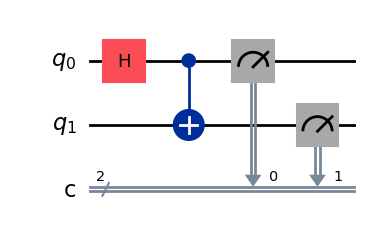

In [23]:
# Escribe tu código aquí
qasm3_string_for_import = '''
OPENQASM 3.0;
include "stdgates.inc";
qubit[2] q;
bit[2] c;
h q[0];
cx q[0], q[1];
c = measure q;
'''

# Your code here
qc_from_qasm = qiskit.qasm3.loads(qasm3_string_for_import)
qc_from_qasm.draw('mpl')

## Ejercicio 18: API de Qiskit IBM Runtime

Las aplicaciones cuánticas modernas normalmente requieren integrar la computación cuántica en flujos de trabajo de software más amplios. IBM Quantum ofrece servicios en la nube a los que se puede acceder desde diversos entornos de programación, además de Python. Se requieren credenciales de autenticación adecuadas para acceder a estos servicios.

Esta es una pregunta conceptual. Estás desarrollando el backend de una aplicación web con Node.js, Go u otro lenguaje distinto de Python, y necesitas enviar trabajos cuánticos a las computadoras cuánticas de IBM. ¿Qué enfoque utilizarías para acceder a los servicios de computación cuántica de IBM y cuál es la información más importante que necesitarías para autenticar tus solicitudes?

In [24]:
# Escribe tu respuesta aquí:
# Utilizarías la API REST de IBM Quantum (que forma parte del servicio
# Qiskit Runtime). La información clave necesaria para la autenticación es tu
# API key de IBM Cloud (correspondiente al servicio actual basado en IBM Cloud).

## Ejercicio 19: ejecutando código en el hardware real de IBM (opcional)

**Importante:** se requiere que hayan configurado correctamente una cuenta de IBM Cloud para acceder a una computadora cuántica a través de la nube.

En un ejercicio anterior, utilizaron la primitiva `Sampler` de `qiskit_ibm_runtime` con el simulador local `AerSimulator`. Acá, ejecutarán la primitiva `Sampler` en una computadora cuántica real de IBM.

Edita el código de abajo de la siguiente forma:
1. Comenta la siguiente línea:
```
backend = AerSimulator()
```
2. Agrega las siguientes líneas inmediatamente después:
```
service = QiskitRuntimeService(name="fallfest-2025")
backend = service.least_busy(operational=True, simulator=False)
```



In [26]:
# your_api_key = "deleteThisAndPasteYourAPIKeyHere"
# your_crn = "deleteThisAndPasteYourCRNHere"

# QiskitRuntimeService.save_account(
#     channel="ibm_quantum_platform",
#     token=your_api_key,
#     instance=your_crn,
#     name="fallfest-2025",
# )

# Check that the account has been saved properly
# service = QiskitRuntimeService(name="fallfest-2025")
# print(service.saved_accounts())

bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

# backend = AerSimulator()
service = QiskitRuntimeService(name="fallfest-2025")
backend = service.least_busy(operational=True, simulator=False)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_bell = pm.run(bell)

sampler = Sampler(mode=backend)

job = sampler.run([isa_bell], shots=5000)
result = job.result()

counts = result[0].data.meas.get_counts()
print(f'Measurement counts: {counts}')